# Phase 2: Data Profiling and Quality Analysis

In [1]:
import sys
from pathlib import Path
import pandas as pd

In [5]:
# Add src to path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

from data.loader import DatasetLoader
from profiling import DataProfiler, ReportGenerator
from visualization import (
    MissingValueVisualizer,
    TargetVisualizer,
    CorrelationVisualizer
)

Loading data...
(307511, 122)
Running profiler...
Generating report...
Generating visualizations...
Profiling complete. Results saved to /workspace/reports
Dataset stats: DatasetStats(rows=307511, columns=122, memory_mb=np.float64(504.98532581329346))
Duplicates: 0
Target analysis: TargetAnalysisReport(positive_count=24825, negative_count=282686, imbalance_ratio=11.387150050352467, baseline_accuracy=91.92711805431351)


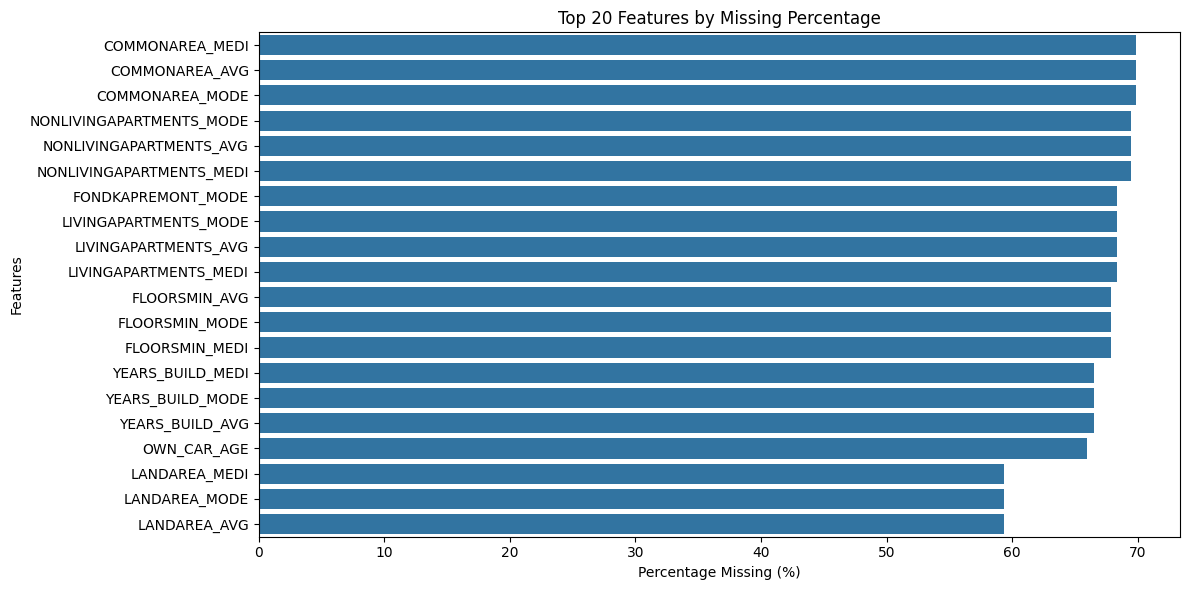

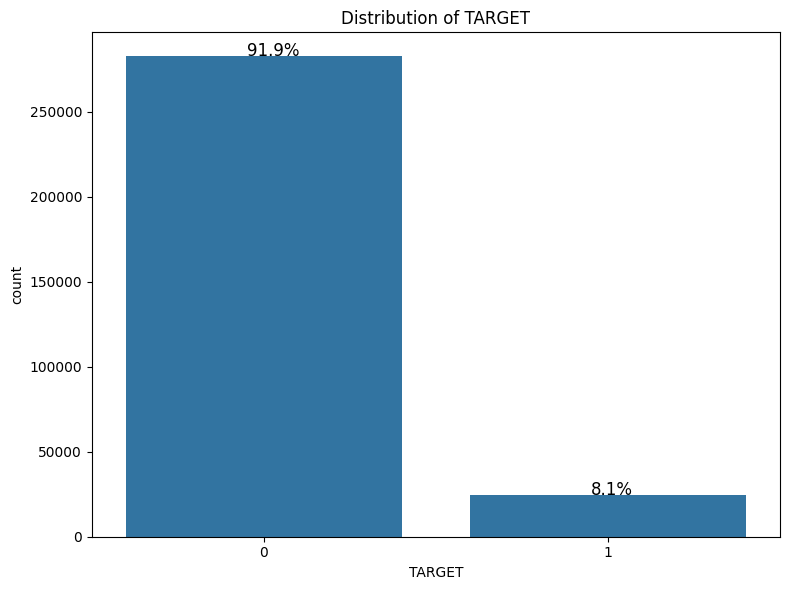

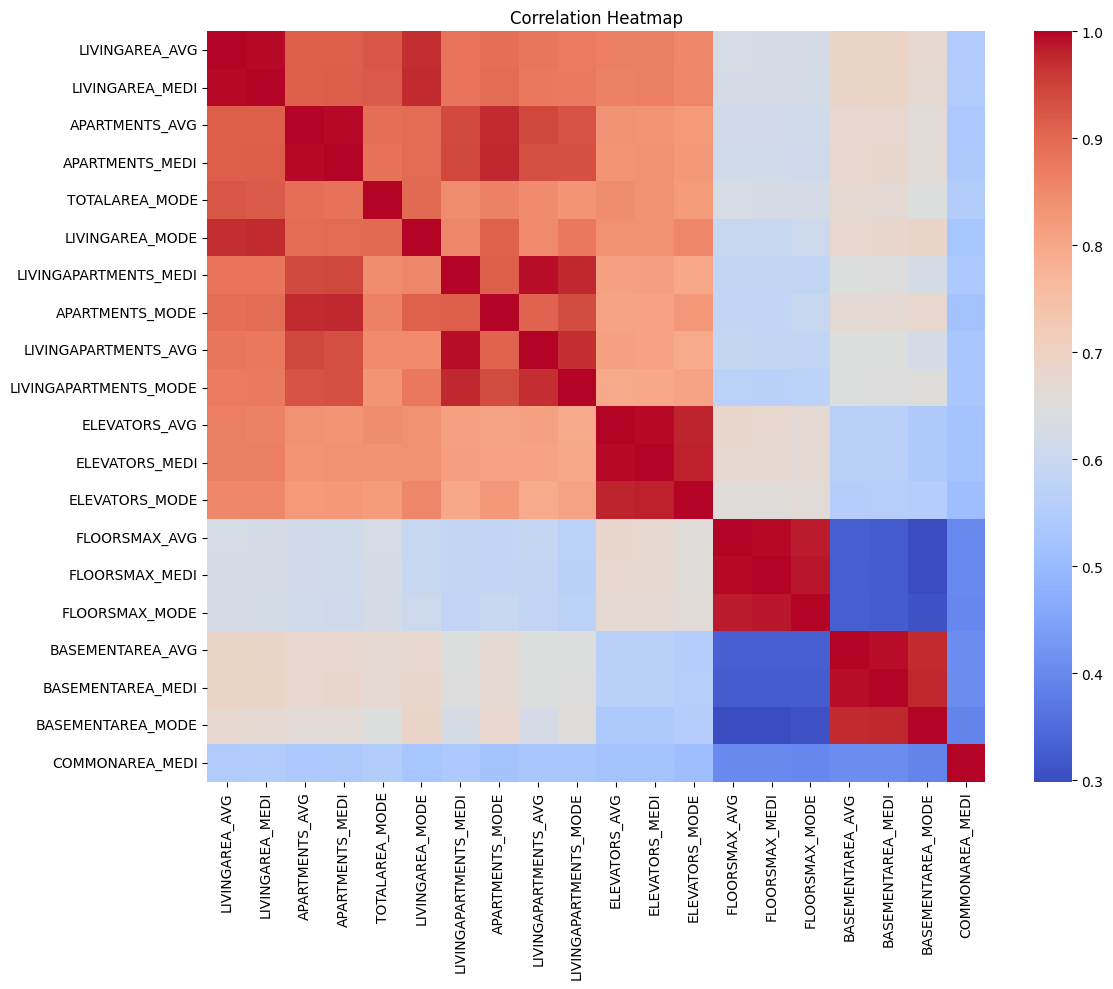

In [7]:
# Setup paths
data_dir = PROJECT_ROOT / "data" / "raw"
reports_dir = PROJECT_ROOT / "reports"

print("Loading data...")
loader = DatasetLoader(data_dir)
df = loader.load_csv("application_train.csv")
print(df.shape)

# Take a sample for faster verification if needed, but let's try full if not too slow
# df = df.sample(10000)

print("Running profiler...")
profiler = DataProfiler(target_column="TARGET")
results = profiler.run(df)

print("Generating report...")
report_gen = ReportGenerator(reports_dir)
report_gen.save_results(results)

print("Generating visualizations...")
mv_fig = MissingValueVisualizer.plot_missing_percentages(results.missing_values.percentages)
report_gen.save_figure(mv_fig, "missing_values.png")

target_fig = TargetVisualizer.plot_distribution(df, "TARGET")
report_gen.save_figure(target_fig, "target_distribution.png")

# Correlation heatmap on numeric columns
corr_fig = CorrelationVisualizer.plot_heatmap(df)
report_gen.save_figure(corr_fig, "correlation_heatmap.png")

print(f"Profiling complete. Results saved to {reports_dir}")
print(f"Dataset stats: {results.dataset_stats}")
print(f"Duplicates: {results.duplicates.duplicate_count}")
print(f"Target analysis: {results.target_analysis}")